# ARIMA Bootstrap — SWH Forecasting

Residual bootstrap CI (no Gaussian assumption). SWH floor at 0m applied.

In [1]:
# ── Cell 1: Environment ──────────────────────────────────────
RUN_ENV  = 'local'
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes'         # change to your path
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ── SWH-specific paths (only change from SLA notebooks) ──────
DATA_FILE = os.path.join(BASE_DIR, 'swh_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_SWH/')
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'TF {tf.__version__} | Env: {RUN_ENV}')
print(f'Data: {DATA_FILE}')
print(f'Save: {SAVE_DIR}')

ARCH='ARIMA'

TF 2.21.0 | Env: local
Data: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\swh_daily_indian_ocean_2021_2023.nc
Save: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/


Loading SWH dataset...
SWH variable detected: VHM0
Period: 2021-01-01 to 2023-12-31 (1095 days)
Grid: lat=-9.80 to 24.80, lon=50.20 to 100.00

Coverage check at each location:
  Arabian_Sea        (15.0N,65.0E) | NaN=0.0% | range=[0.587, 6.220]m ✓
  Bay_of_Bengal      (12.0N,87.0E) | NaN=0.0% | range=[0.699, 4.966]m ✓
  Andaman_Sea        (11.0N,95.0E) | NaN=0.0% | range=[0.466, 3.289]m ✓
  Lakshadweep        (10.0N,73.0E) | NaN=0.0% | range=[0.651, 4.692]m ✓
  South_IO           (-5.0N,75.0E) | NaN=0.0% | range=[1.046, 4.220]m ✓

NOTE: SWH > 0 always. NaN means ice-covered or land-masked cells.
If NaN > 20% at a location, consider shifting 1-2 degrees offshore.


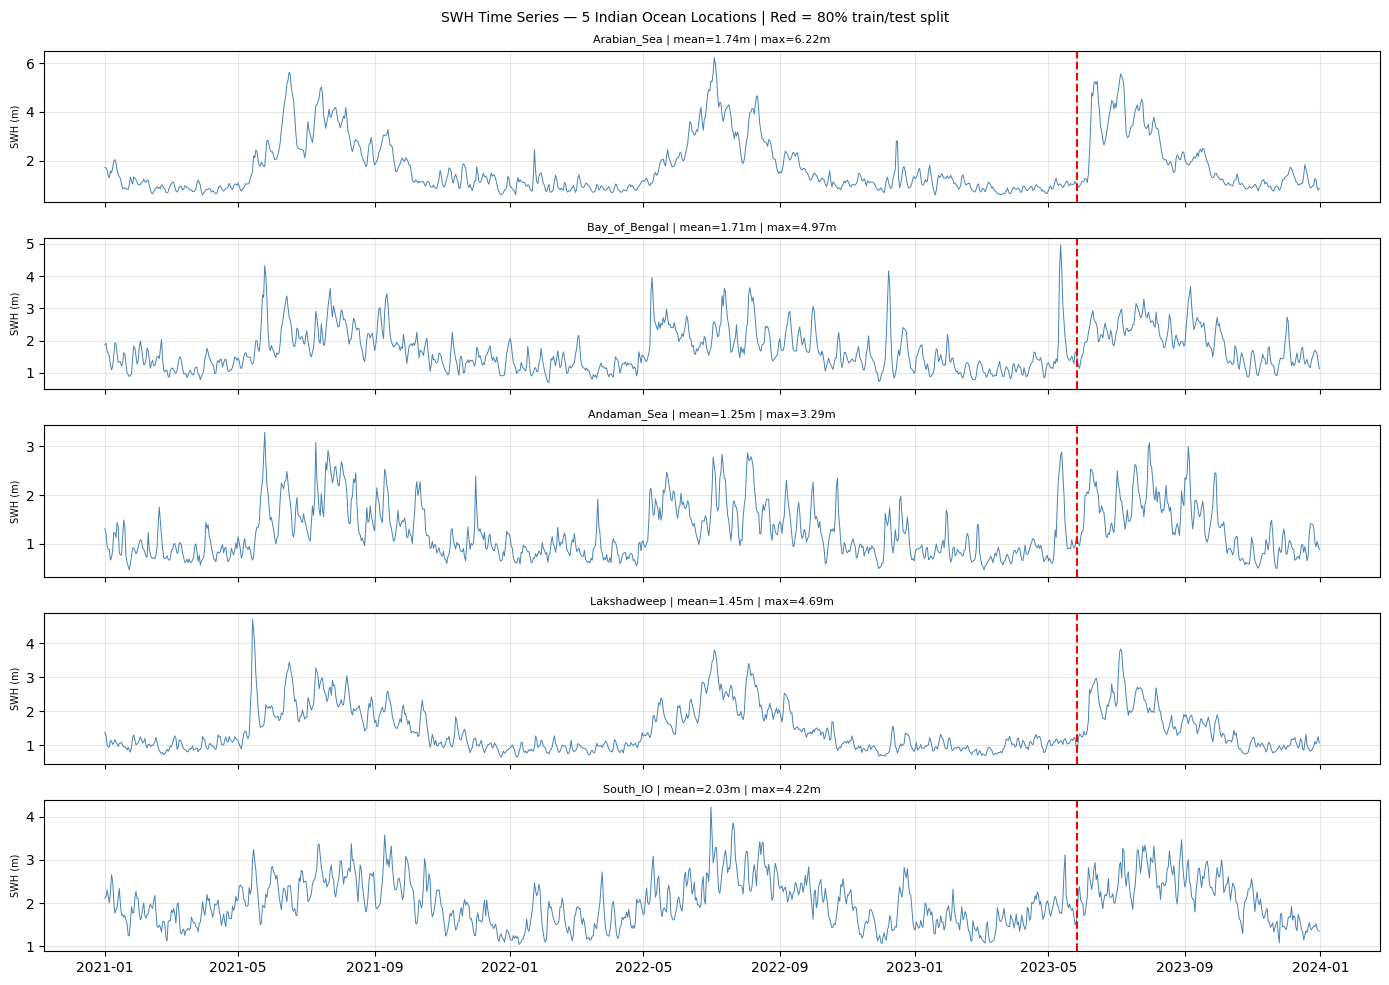

In [2]:
# ── Cell 2: Load SWH Data ────────────────────────────────────
# Same 5 Indian Ocean locations as SLA study (same coordinates,
# same period 2021-2023) — enables direct SLA vs SWH comparison.
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),
    'Bay_of_Bengal': (12.0, 87.0),
    'Andaman_Sea':   (11.0, 95.0),
    'Lakshadweep':   (10.0, 73.0),
    'South_IO':      (-5.0, 75.0),
}

print('Loading SWH dataset...')
ds = xr.open_dataset(DATA_FILE)
ds = ds.resample(time='1D').mean()
times_index = pd.to_datetime(ds['time'].values)

# ── Auto-detect SWH variable name ───────────────────────────
# CMEMS products use different names depending on the product:
# 'VHM0'  → ERA5-based reanalysis / wave model reanalysis
# 'hs'    → some hindcast products
# 'swh'   → alternative naming
SWH_VAR = None
for candidate in ['VHM0', 'hs', 'swh', 'SWH', 'Hs']:
    if candidate in ds.data_vars:
        SWH_VAR = candidate
        break
if SWH_VAR is None:
    print("Available variables:", list(ds.data_vars))
    raise ValueError("Cannot find SWH variable. Set SWH_VAR manually above.")

print(f'SWH variable detected: {SWH_VAR}')
print(f'Period: {times_index[0].date()} to {times_index[-1].date()} ({len(times_index)} days)')
print(f'Grid: lat={float(ds.latitude.min()):.2f} to {float(ds.latitude.max()):.2f}, '
      f'lon={float(ds.longitude.min()):.2f} to {float(ds.longitude.max()):.2f}')

# ── Coverage + NaN check ─────────────────────────────────────
print('\nCoverage check at each location:')
for loc, (lat, lon) in LOCATIONS.items():
    swh = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    nan_pct = np.isnan(swh).mean() * 100
    valid   = swh[~np.isnan(swh)]
    rng     = f"[{valid.min():.3f}, {valid.max():.3f}]m" if len(valid) > 0 else "ALL NaN"
    flag    = " ⚠️ HIGH NaN" if nan_pct > 20 else " ✓"
    print(f'  {loc:<18} ({lat:.1f}N,{lon:.1f}E) | NaN={nan_pct:.1f}% | range={rng}{flag}')

print()
print('NOTE: SWH > 0 always. NaN means ice-covered or land-masked cells.')
print('If NaN > 20% at a location, consider shifting 1-2 degrees offshore.')

# ── Quick time series plot ────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
for ax, (loc, (lat, lon)) in zip(axes, LOCATIONS.items()):
    swh = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    ax.plot(times_index, swh, lw=0.7, color='steelblue')
    n_train = int(len(swh)*0.80)
    ax.axvline(times_index[n_train], color='red', lw=1.5, ls='--')
    ax.set_title(f'{loc} | mean={np.nanmean(swh):.2f}m | max={np.nanmax(swh):.2f}m', fontsize=8)
    ax.set_ylabel('SWH (m)', fontsize=7); ax.grid(True, alpha=0.3)
fig.suptitle('SWH Time Series — 5 Indian Ocean Locations | Red = 80% train/test split', fontsize=10)
plt.tight_layout(); plt.show()

In [3]:
# ── Cell 3: Config + All Helpers ─────────────────────────────
TRAIN_SPLIT  = 0.80
SEQ_LEN      = 30     # 30-day lookback (same as SLA)
EPOCHS       = 100
BATCH_SIZE   = 64
LR           = 0.001
PATIENCE     = 20
VAL_SPLIT    = 0.10
SEEDS        = [42, 7, 13, 99, 2025]
TUBE_R       = 0.5
TUBE_DELTA   = 0.01
MIN_WIDTH    = 0.05   # ← SWH: 5 cm minimum width (SLA used 0.005 m)
                      #   SWH varies by metres so minimum is larger
DROPOUT      = 0.2
ALPHA_WIS    = 0.20   # p10/p90 intervals
TARGET_PICP  = 0.95

print(f'SEQ_LEN={SEQ_LEN} | EPOCHS={EPOCHS} | BATCH={BATCH_SIZE} | {len(SEEDS)} seeds')
print(f'Tube: r={TUBE_R}, delta={TUBE_DELTA} | MIN_WIDTH={MIN_WIDTH}m (5cm for SWH)')

# ─── Data splits with SWH-specific NaN handling ───────────────
def get_splits(loc_name):
    lat, lon = LOCATIONS[loc_name]
    swh_raw = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    # Linear interpolation for gaps ≤ 14 days, then forward-fill
    s = pd.Series(swh_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    # SWH FLOOR: wave height cannot be negative (unlike SLA)
    s = s.clip(lower=0.0)
    data = s.values

    n = len(data); n_train = int(n * TRAIN_SPLIT); n_test = n - n_train
    scaler  = RobustScaler()
    train_s = scaler.fit_transform(data[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(data[n_train:].reshape(-1,1)).flatten()
    combined = np.concatenate([train_s, test_s])

    X_tr = np.array([train_s[i:i+SEQ_LEN] for i in range(len(train_s)-SEQ_LEN)])[..., np.newaxis]
    y_tr = np.array([train_s[i+SEQ_LEN]   for i in range(len(train_s)-SEQ_LEN)])
    X_te = np.array([combined[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])
    return dict(X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te,
                scaler=scaler, n_train=n_train, n_test=n_test, raw=data)

# ─── Loss functions (identical to SLA — MIN_WIDTH handles scale) ──
def build_quantile_loss(scaler, q_lo=0.10, q_hi=0.90):
    min_ws = float(abs(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0]))
    def loss(yt, yp):
        true = yt[:,0:1]; lo = yp[:,0:1]; hi = yp[:,1:2]
        elo, ehi = true-lo, true-hi
        return (tf.reduce_mean(tf.maximum(q_lo*elo,(q_lo-1)*elo))
              + tf.reduce_mean(tf.maximum(q_hi*ehi,(q_hi-1)*ehi))
              + tf.reduce_mean(tf.nn.relu(lo-hi))
              + tf.reduce_mean(tf.nn.relu(min_ws-(hi-lo))))
    return loss

def build_tube_loss(scaler, r=TUBE_R, delta=TUBE_DELTA):
    min_ws = float(abs(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0]))
    def loss(yt, yp):
        true = yt[:,0:1]; lo = yp[:,0:1]; hi = yp[:,1:2]
        return (tf.reduce_mean((1-r)*tf.nn.relu(lo-true) + r*tf.nn.relu(true-hi)
                + delta*tf.abs(hi-lo) + tf.nn.relu(lo-hi))
              + tf.reduce_mean(tf.nn.relu(min_ws-(hi-lo))))
    return loss

# ─── Evaluation — SWH FLOOR applied after inverse_transform ──
def evaluate(y_true_s, y_pred_raw, scaler):
    lo_m = scaler.inverse_transform(y_pred_raw[:,0:1]).flatten()
    hi_m = scaler.inverse_transform(y_pred_raw[:,1:2]).flatten()
    y_m  = scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()
    if np.any(np.isnan(lo_m)) or np.any(np.isnan(hi_m)):
        return np.nan, np.nan, np.nan, np.nan, lo_m, hi_m, y_m
    lo = np.maximum(np.minimum(lo_m, hi_m), 0.0)  # swap + floor at 0
    hi = np.maximum(np.maximum(lo_m, hi_m), 0.0)  # SWH cannot be negative
    picp = float(np.mean((y_m >= lo) & (y_m <= hi))) * 100.0
    mpiw = float(np.mean(hi - lo))
    wis  = float(np.mean((hi-lo)+(2/ALPHA_WIS)*np.maximum(0,lo-y_m)+(2/ALPHA_WIS)*np.maximum(0,y_m-hi)))
    cwc  = mpiw if picp/100 >= TARGET_PICP else mpiw*np.exp(-50*(picp/100-TARGET_PICP))
    return picp, mpiw, wis, cwc, lo, hi, y_m

# ─── Model builder ────────────────────────────────────────────
# ARIMA uses statsmodels, not keras
def build_model(): pass

print('All helpers defined. Proceed to Cell 4.')

SEQ_LEN=30 | EPOCHS=100 | BATCH=64 | 5 seeds
Tube: r=0.5, delta=0.01 | MIN_WIDTH=0.05m (5cm for SWH)
All helpers defined. Proceed to Cell 4.


In [4]:
# Cell 4 — ARIMA Bootstrap (no Gaussian assumption)
try:
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller
    STATS_OK = True
except ImportError:
    print("pip install statsmodels"); STATS_OK = False

ARIMA_ORDER  = (2,1,1)
N_BOOTSTRAP  = 2000
all_results  = []

if STATS_OK:
    for loc_name,(lat,lon) in LOCATIONS.items():
        print(f'\n{"="*55}')
        print(f'  ARIMA{ARIMA_ORDER} @ {loc_name}')
        print(f'{"="*55}')
        swh_raw=ds[SWH_VAR].sel(latitude=lat,longitude=lon,method='nearest').values.flatten()
        s=pd.Series(swh_raw,index=times_index).interpolate(method='time',limit=14).ffill().bfill()
        s=s.clip(lower=0); data=s.values
        n_train=int(len(data)*TRAIN_SPLIT); train=data[:n_train]; test=data[n_train:]
        _,p_adf,*_=adfuller(train,autolag='AIC')
        print(f'  ADF p={p_adf:.4f} ({"stationary" if p_adf<0.05 else "non-stationary -> d=1 appropriate"})')
        try:
            fit_full=ARIMA(train,order=ARIMA_ORDER).fit(method_kwargs={"warn_convergence":False})
            resid=fit_full.resid.values; resid=resid[~np.isnan(resid)]
            std_r=np.std(resid); resid=resid[np.abs(resid)<=5*std_r]
            print(f'  Training residuals: n={len(resid)}, std={std_r:.4f}m')
        except Exception as e:
            print(f'  Fallback residuals: {e}')
            resid=np.random.normal(0,np.std(np.diff(train)),500)
        lo_p,hi_p,mu_p=[],[],[]
        history=list(train)
        for t in range(len(test)):
            if t%50==0: print(f'  Step {t}/{len(test)}...',end=' ',flush=True)
            try:
                fc=ARIMA(history,order=ARIMA_ORDER).fit(method_kwargs={"warn_convergence":False}).get_forecast(1)
                mu_=float(fc.predicted_mean.iloc[0])
            except: mu_=history[-1]
            boot=mu_+np.random.choice(resid,N_BOOTSTRAP,replace=True)
            lo_=max(0,float(np.quantile(boot,0.025)))   # SWH floor
            hi_=max(0,float(np.quantile(boot,0.975)))
            mu_p.append(mu_); lo_p.append(lo_); hi_p.append(hi_)
            history.append(test[t])
        lo_m=np.array(lo_p); hi_m=np.array(hi_p); y_m=test
        lo=np.minimum(lo_m,hi_m); hi=np.maximum(lo_m,hi_m)
        picp=float(np.mean((y_m>=lo)&(y_m<=hi)))*100
        mpiw=float(np.mean(hi-lo))
        wis=float(np.mean((hi-lo)+(2/ALPHA_WIS)*np.maximum(0,lo-y_m)+(2/ALPHA_WIS)*np.maximum(0,y_m-hi)))
        cwc=mpiw if picp/100>=TARGET_PICP else mpiw*np.exp(-50*(picp/100-TARGET_PICP))
        print()
        print(f'  PICP={picp:.1f}%  MPIW={mpiw:.4f}m  WIS={wis:.4f}  CWC={cwc:.5f}')
        all_results.append(dict(
            location=loc_name,lat=lat,lon=lon,model=f'ARIMA{ARIMA_ORDER}-Bootstrap',
            avg_picp=picp,std_picp=0.0,avg_mpiw=mpiw,std_mpiw=0.0,
            avg_wis=wis,std_wis=0.0,avg_cwc=cwc,std_cwc=0.0,
            n_seeds=1,n_train_seqs=n_train,n_test_pts=len(test),seq_len=1,
            arima_order=str(ARIMA_ORDER),n_bootstrap=N_BOOTSTRAP))
    df=pd.DataFrame(all_results)
    csv_path=os.path.join(SAVE_DIR,'results_ARIMA_SWH.csv')
    df.to_csv(csv_path,index=False)
    print(f'\nSaved: {csv_path}')
    print(df[['location','avg_picp','avg_mpiw','avg_wis','avg_cwc']].to_string(index=False))


  ARIMA(2, 1, 1) @ Arabian_Sea
  ADF p=0.0121 (stationary)
  Fallback residuals: 'numpy.ndarray' object has no attribute 'values'
  Step 0/219...   Step 50/219...   Step 100/219...   Step 150/219...   Step 200/219... 
  PICP=94.1%  MPIW=0.8397m  WIS=1.0401  CWC=1.34092

  ARIMA(2, 1, 1) @ Bay_of_Bengal
  ADF p=0.0463 (stationary)
  Fallback residuals: 'numpy.ndarray' object has no attribute 'values'
  Step 0/219...   Step 50/219...   Step 100/219...   Step 150/219...   Step 200/219... 
  PICP=99.1%  MPIW=1.0584m  WIS=1.0691  CWC=1.05843

  ARIMA(2, 1, 1) @ Andaman_Sea
  ADF p=0.0010 (stationary)
  Fallback residuals: 'numpy.ndarray' object has no attribute 'values'
  Step 0/219...   Step 50/219...   Step 100/219...   Step 150/219...   Step 200/219... 
  PICP=93.2%  MPIW=0.8520m  WIS=0.9393  CWC=2.14790

  ARIMA(2, 1, 1) @ Lakshadweep
  ADF p=0.0889 (non-stationary -> d=1 appropriate)
  Fallback residuals: 'numpy.ndarray' object has no attribute 'values'
  Step 0/219...   Step 50/219..